# EDA for Events data

Loda the data

In [1]:
import pandas as pd
from sqlalchemy import create_engine
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns


In [2]:
from sqlalchemy import create_engine

DBDIR = "C:\\Users\\VishwasKSingh\\Workspace\\kantar-workspace-1\\my_project\\dbs"
engine = create_engine(f"sqlite:///{DBDIR}/events.db")

with engine.begin() as conn:
    df = pd.read_sql_table(
        table_name="events",
        con = conn
    )

df.head()

,event_id,topic,city_x,venue_capacity,scheduled_date_time,instructor_id,base_price,discount_code,discount_pct,currency,...,role,city_y,industry,notes,first_contact_channel,registration_lead_days,event_day_of_week,channel,spend,impressions
0,E001,Python OOP,Bengaluru,50,2026-01-13 10:00:00,I001,3000,STUDENT15,15,INR,...,Student,Pune,IT,Reached via partner. Promo=STUDENT15; Phone:+9...,partner,13,Tuesday,email,7000,35000
1,E001,Python OOP,Bengaluru,50,2026-01-13 10:00:00,I001,3000,STUDENT15,15,INR,...,Student,Pune,IT,Reached via partner. Promo=STUDENT15; Phone:+9...,partner,13,Tuesday,social,5000,10000
2,E001,Python OOP,Bengaluru,50,2026-01-13 10:00:00,I001,3000,STUDENT15,15,INR,...,Student,Pune,IT,Reached via partner. Promo=STUDENT15; Phone:+9...,partner,13,Tuesday,partner,7000,20000
3,E001,Python OOP,Bengaluru,50,2026-01-13 10:00:00,I001,3000,STUDENT15,15,INR,...,Engineer,Mysuru,Education,Reached via email. Promo=STUDENT15; Phone:+91-...,email,26,Tuesday,email,7000,35000
4,E001,Python OOP,Bengaluru,50,2026-01-13 10:00:00,I001,3000,STUDENT15,15,INR,...,Engineer,Mysuru,Education,Reached via email. Promo=STUDENT15; Phone:+91-...,email,26,Tuesday,social,5000,10000


Descriptive statisical values

In [3]:
df.describe()

,venue_capacity,scheduled_date_time,base_price,discount_pct,effective_price,reg_timestamp,registration_lead_days,spend,impressions
count,1263.000000,1263,1263.000000,1263.000000,1263.000000,1263,1263.000000,1263.000000,1263.000000
mean,47.624703,2026-01-30 01:01:08.408551168,2580.760095,17.850356,2113.004751,2026-01-14 01:21:39.762470400,15.985748,5308.788599,23578.780681
min,30.000000,2026-01-13 10:00:00,2000.000000,0.000000,1500.000000,2025-12-14 10:00:00,2.000000,3000.000000,10000.000000
25%,40.000000,2026-01-22 10:00:00,2000.000000,15.000000,1700.000000,2026-01-05 11:00:00,9.000000,5000.000000,10000.000000
50%,50.000000,2026-01-28 11:00:00,3000.000000,15.000000,2250.000000,2026-01-13 14:00:00,16.000000,5000.000000,20000.000000
75%,60.000000,2026-02-06 10:00:00,3000.000000,25.000000,2250.000000,2026-01-23 11:00:00,23.000000,7000.000000,35000.000000
max,60.000000,2026-02-15 11:00:00,3000.000000,25.000000,2700.000000,2026-02-13 11:00:00,30.000000,7000.000000,35000.000000
std,10.206820,NaN,460.622529,7.767354,384.230839,NaN,8.375581,1557.043311,10961.100768


Unique city and their counts

In [4]:
df['city_x'].value_counts()

city_x
Bengaluru    711
Mysuru       381
Hyderabad    111
Pune          60
Name: count, dtype: int64

In [5]:
df['city_y'].value_counts()

city_y
Pune         567
Bengaluru    288
Mysuru       222
Hyderabad    186
Name: count, dtype: int64

Distribution of payment status

In [6]:
df['payment_status'].value_counts()

payment_status
paid         426
cancelled    420
pending      417
Name: count, dtype: int64

In [7]:
df.groupby('event_id')['payment_status'].value_counts()

event_id  payment_status
E001      paid              33
          cancelled         27
          pending           21
E002      paid              33
          pending           33
          cancelled         21
E003      cancelled         42
          paid              42
          pending           24
E004      cancelled         66
          paid              54
          pending           54
E005      paid              51
          cancelled         33
          pending           33
E006      pending           36
          paid              27
          cancelled         18
E007      pending           27
          paid              21
          cancelled         12
E008      pending           63
          paid              45
          cancelled         36
E009      cancelled         54
          paid              33
          pending           24
E010      pending           36
          paid              33
          cancelled         27
E011      cancelled         36
          pend

# Generating the Visualizations

Text(0, 0.5, 'Number of Registrations')

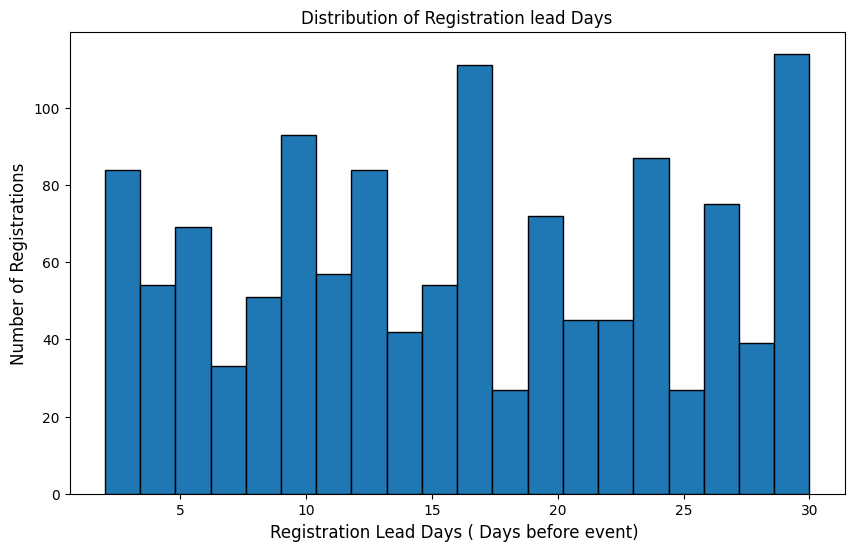

In [8]:
plt.figure(figsize=(10,6))
df_plot = df[df['registration_lead_days'] <= 90].copy()
plt.hist(df_plot['registration_lead_days'], bins=20, edgecolor='black',color='#1F77B4')
plt.title("Distribution of Registration lead Days")
plt.xlabel("Registration Lead Days ( Days before event) ",fontsize=12)
plt.ylabel("Number of Registrations", fontsize=12)

C:\Users\VishwasKSingh\AppData\Local\Temp\ipykernel_12992\215119084.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='payment_status', y='effective_price', data=df, palette='Pastel1')


<Axes: xlabel='payment_status', ylabel='effective_price'>

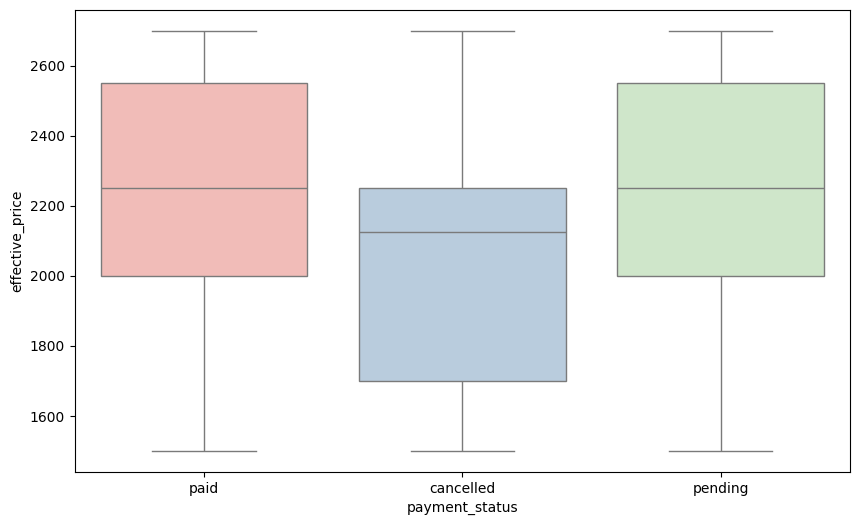

In [9]:
plt.figure(figsize=(10,6))
sns.boxplot(x='payment_status', y='effective_price', data=df, palette='Pastel1')

which topics have highest registrations

In [10]:
df['topic'].value_counts()

topic
Python OOP                     630
Machine Learning Essentials    468
Data Wrangling                 165
Name: count, dtype: int64

C:\Users\VishwasKSingh\AppData\Local\Temp\ipykernel_12992\3130173757.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_topics.index, y=top_topics.values, palette="viridis")


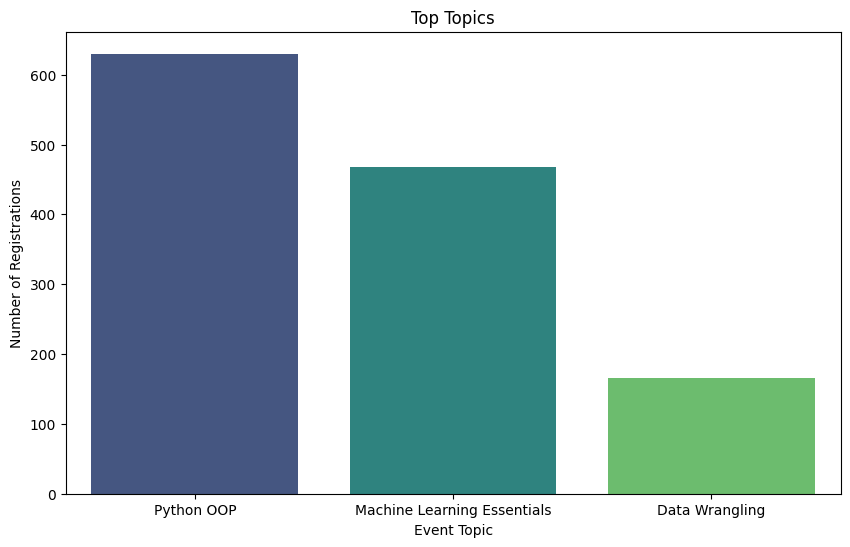

In [13]:
top_topics = df['topic'].value_counts()
plt.figure(figsize=(10,6))
sns.barplot(x=top_topics.index, y=top_topics.values, palette="viridis")
plt.title("Top Topics")
plt.xlabel("Event Topic")
plt.ylabel("Number of Registrations")
# plt.xticks(rotation=45)
plt.show()

In [14]:
df.columns

Index(['event_id', 'topic', 'city_x', 'venue_capacity', 'scheduled_date_time',
       'instructor_id', 'base_price', 'discount_code', 'discount_pct',
       'currency', 'effective_price', 'reg_id', 'attendee_email',
       'reg_timestamp', 'payment_status', 'ticket_type', 'company', 'role',
       'city_y', 'industry', 'notes', 'first_contact_channel',
       'registration_lead_days', 'event_day_of_week', 'channel', 'spend',
       'impressions'],
      dtype='object')